**Clustering Tipe Pengguna Media Sosial**

**Anggota Kelompok:**

1. Said Hasan Nasrallah (19250671) -Ketua 
2. Tata Dwi Tama Puta (19250729)
3. Shabryan Khaylani (19250936)
4. Hon Zie Kaori (19251001)
5. Sheren Putri Toisuta (19250707)

### 1. BUSSINES UNDERSTANDING


**a. Latar belakang Pemilihan Dataset:**


Penggunaan media sosial telah menjadi bagian yang tidak terpisahkan dari kehidupan masyarakat modern. Namun, di balik kemudahannya, penggunaan yang tidak terkontrol sering kali menimbulkan fenomena social media fatigue (kelelahan media sosial) dan dampak psikologis yang serius. Sebagaimana dinyatakan oleh (Putri & Aviani, 2023), penggunaan media sosial yang intensif dapat memicu peningkatan gejala stres pada individu akibat adanya ketidaksesuaian antara ekspektasi digital dengan kenyataan hidup yang dialami.
Masalah kesehatan mental seperti kecemasan, depresi, dan gangguan tidur kini menjadi perhatian serius dalam interaksi digital. Berbagai studi menunjukkan adanya keterkaitan antara durasi penggunaan media sosial dengan kondisi emosional penggunanya. Namun, setiap individu memiliki pola perilaku yang berbeda-beda — ada yang tetap stabil meski aktif menggunakan media sosial, namun ada juga yang sangat rentan terhadap dampak negatif meski durasi penggunaannya singkat. Hal ini menunjukkan bahwa belum adanya pengelompokan yang jelas mengenai tipe-tipe pengguna berdasarkan perilaku dan dampak kesehatan mental mereka, sehingga sulit untuk memahami karakteristik masing-masing tipe secara spesifik.
Dalam konteks Data Science, pendekatan Unsupervised Learning melalui algoritma Clustering memberikan solusi untuk mengelompokkan karakteristik pengguna tanpa memerlukan pelabelan manual. Hal ini sejalan dengan urgensi yang disampaikan oleh (Al Yasin, dkk., 2022), bahwa identifikasi dampak media sosial sangat penting sebagai langkah preventif untuk meminimalisir risiko kesehatan mental dan fisik jangka panjang. Oleh karena itu, penelitian ini memanfaatkan dataset Social Media and Mental Health yang berisi hasil survei terhadap 481 responden dengan 21 variabel, mencakup data demografi, kebiasaan penggunaan media sosial, serta dampaknya terhadap kesehatan mental. Dataset ini dianalisis menggunakan metode K-Means Clustering untuk menemukan pengelompokan alami tipe pengguna media sosial. Analisis ini diharapkan mampu memberikan kontribusi dalam memahami pola perilaku digital sekaligus mendukung upaya preventif terhadap dampak negatif penggunaan media sosial secara berlebihan.




**b. Tujuan**

Tujuan dari penelitian ini adalah:

1. Mengelompokkan pengguna media sosial berdasarkan perilaku penggunaan dan dampak kesehatan mental menggunakan algoritma K-Means Clustering
2. Mengidentifikasi karakteristik dan pola dari masing-masing tipe pengguna yang terbentuk
3. Memberikan insight mengenai hubungan antara intensitas penggunaan media sosial dengan kondisi kesehatan mental pengguna

**C. Manfaat**

- **Pengguna sosmed** — Dapat mengetahui mereka termasuk tipe pengguna yang mana dan mengevaluasi kebiasaan digital mereka sendiri
- **Platform sosmed** — Dapat mengembangkan fitur yang lebih sehat seperti *screen time reminder* yang ditargetkan untuk tipe *Heavy User*
- **Psikolog / Peneliti** — Dapat mengidentifikasi kelompok mana yang paling berisiko mengalami gangguan mental health akibat penggunaan media sosial

**d. Mengapa Menggunakan Clustering?**


Metode clustering dipilih karena dataset ini tidak memiliki label atau kategori pengguna yang sudah ditentukan sebelumnya. Tidak ada kolom yang bertuliskan "Heavy User" atau "Casual User" — kita tidak tahu dari awal ada berapa tipe pengguna dan siapa masuk ke tipe mana. Maka dari itu digunakan unsupervised learning yaitu K-Means Clustering yang bertugas menemukan pengelompokan alami dari data tanpa membutuhkan label.

In [2]:
import pandas as pd
file= "smmh.csv"
df=pd.read_csv(file)

Membaca File dan ubah jadi dataframe menggunakan Pandas

### 2. DATA UNDERSTANDING

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    object 
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    object 
 3   3. Relationship Status                                                                                                481 non-null    object 
 4   4. Occup



Berdasarkan hasil `df.info()`, dataset memiliki **481 data** dengan total **21 kolom**.

# a. Informasi Dataset
- `int64` : 12 kolom
- `object` : 8 kolom
- `float64` : 1 kolom

Terdapat missing value pada kolom:
- `What type of organizations are you affiliated with?`

karena jumlah non-null hanya **451 data**.

### Analisis Awal
Dataset berisi data mengenai:
- identitas responden,
- penggunaan media sosial,
- serta dampak psikologis yang dirasakan pengguna.

Beberapa kolom numerik nantinya digunakan dalam proses clustering menggunakan metode K-Means.

In [4]:
df.describe()

,1. What is your age?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
count,481.00000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,26.13659,3.553015,3.320166,2.588358,3.349272,3.559252,3.245322,2.831601,2.775468,2.455301,3.255717,3.170478,3.201663
std,9.91511,1.096299,1.328137,1.257059,1.175552,1.283356,1.347105,1.407835,1.056479,1.247739,1.313033,1.256666,1.461619
min,13.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.00000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
50%,22.00000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000
75%,26.00000,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,5.000000
max,91.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## b. Statistik Deskriptif Dataset

Berdasarkan hasil statistik deskriptif (`describe()`), dataset memiliki total **481 responden** pada setiap kolom numerik.

### Hasil Analisis Awal

- Rata-rata umur responden adalah sekitar **26 tahun**.
- Nilai rata-rata pada beberapa fitur seperti:
  - penggunaan media sosial tanpa tujuan,
  - distraksi,
  - kekhawatiran,
  - dan gangguan tidur

  berada di kisaran **3** dari skala 1–5, yang menunjukkan bahwa responden cukup sering mengalami dampak penggunaan media sosial.

- Nilai minimum pada sebagian besar fitur adalah **1**, sedangkan nilai maksimum mencapai **5**, sesuai dengan skala kuesioner yang digunakan.

- Standar deviasi pada tiap fitur berkisar antara **1.0 – 1.4**, yang menunjukkan adanya variasi jawaban antar responden.

### Kesimpulan Sementara

Berdasarkan statistik deskriptif, data menunjukkan adanya variasi perilaku dan kondisi psikologis pengguna media sosial. Oleh karena itu, dataset cukup relevan untuk dilakukan proses clustering guna menemukan pola kelompok pengguna media sosial.

In [5]:
print(f"Mengecek Jumlah Missing Value di tiap kolom\n {df.isnull().sum()} \n")
print(f"Apakah ada nilai unik di tiap baris? \n {df.duplicated().sum()}\n")

Mengecek Jumlah Missing Value di tiap kolom
 Timestamp                                                                                                                0
1. What is your age?                                                                                                     0
2. Gender                                                                                                                0
3. Relationship Status                                                                                                   0
4. Occupation Status                                                                                                     0
5. What type of organizations are you affiliated with?                                                                  30
6. Do you use social media?                                                                                              0
7. What social media platforms do you commonly use?                                           

## c. cek Kualitas Data

Pada tahap ini dilakukan pengecekan terhadap missing value dan data duplikat pada dataset.

### Hasil Pengecekan Missing Value

Berdasarkan hasil pengecekan, hampir seluruh kolom tidak memiliki missing value. Namun, terdapat missing value pada kolom:

- `What type of organizations are you affiliated with?`

sebanyak **30 data kosong**.

### Hasil Pengecekan Data Duplikat

Hasil pengecekan menunjukkan bahwa:
- jumlah data duplikat = **0**

Sehingga tidak ditemukan baris data yang terduplikasi pada dataset.

### Kesimpulan

Dataset secara umum memiliki kualitas data yang cukup baik karena:
- sebagian besar kolom tidak memiliki missing value,
- dan tidak ditemukan data duplikat.

Namun, kolom yang memiliki missing value perlu ditangani pada tahap preprocessing sebelum proses clustering dilakukan.

In [6]:
df.nunique()

Timestamp                                                                                                               480
1. What is your age?                                                                                                     46
2. Gender                                                                                                                 9
3. Relationship Status                                                                                                    4
4. Occupation Status                                                                                                      4
5. What type of organizations are you affiliated with?                                                                   18
6. Do you use social media?                                                                                               2
7. What social media platforms do you commonly use?                                                                     125
8. What 

### 3. DATA PREPARATION

In [7]:
kolom_baru = {
    'Timestamp': 'waktu',
    '1. What is your age?': 'umur',
    '2. Gender': 'kelamin',
    '3. Relationship Status': 'status umum',
    '4. Occupation Status': 'status pekerjaan',
    '5. What type of organizations are you affiliated with?': 'organisasi yang terhubung',
    '6. Do you use social media?': 'apakah kamu pengguna media sosial?',
    '7. What social media platforms do you commonly use?': 'platform media sosial',
    '8. What is the average time you spend on social media every day?': 'rata-rata waktu penggunaan media sosial per hari',
    '9. How often do you find yourself using Social media without a specific purpose?': 'scroll tanpa tujuan',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'distraksi sosmed',
    "11. Do you feel restless if you haven't used Social media in a while?": 'ketergantungan sosmed',
    '12. On a scale of 1 to 5, how easily distracted are you?' : 'mudah_terdistraksi',
    '13. On a scale of 1 to 5, how much are you bothered by worries?' : 'kekhawatiran',
    '14. Do you find it difficult to concentrate on things?' : 'kesulitan konsentrasi',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?' : 'perbandingan diri sosmed',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?' : 'dampak perbandingan',
    '17. How often do you look to seek validation from features of social media?' : 'haus validasi',
    '18. How often do you feel depressed or down?' : 'depresi',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?' : 'mood tidak stabil',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?' : 'gangguan tidur',
}
df2=df.rename(columns=kolom_baru)
df2.head(2)

,waktu,umur,kelamin,status umum,status pekerjaan,organisasi yang terhubung,apakah kamu pengguna media sosial?,platform media sosial,rata-rata waktu penggunaan media sosial per hari,scroll tanpa tujuan,...,ketergantungan sosmed,mudah_terdistraksi,kekhawatiran,kesulitan konsentrasi,perbandingan diri sosmed,dampak perbandingan,haus validasi,depresi,mood tidak stabil,gangguan tidur
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5


In [8]:
kolom_tidak_digunakan=['waktu','apakah kamu pengguna media sosial?','organisasi yang terhubung','platform media sosial']
df3=df2.drop(columns=kolom_tidak_digunakan)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 17 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   umur                                              481 non-null    float64
 1   kelamin                                           481 non-null    object 
 2   status umum                                       481 non-null    object 
 3   status pekerjaan                                  481 non-null    object 
 4   rata-rata waktu penggunaan media sosial per hari  481 non-null    object 
 5   scroll tanpa tujuan                               481 non-null    int64  
 6   distraksi sosmed                                  481 non-null    int64  
 7   ketergantungan sosmed                             481 non-null    int64  
 8   mudah_terdistraksi                                481 non-null    int64  
 9   kekhawatiran         

In [9]:
waktu_penggunaan = {
    'Less than an Hour': 1,
    'Between 1 and 2 hours': 2,
    'Between 2 and 3 hours': 3,
    'Between 3 and 4 hours': 4,
    'Between 4 and 5 hours': 5,
    'More than 5 hours': 6
}
df3['rata-rata waktu penggunaan media sosial per hari'] = df3['rata-rata waktu penggunaan media sosial per hari'].map(waktu_penggunaan)
df3.head(10)

,umur,kelamin,status umum,status pekerjaan,rata-rata waktu penggunaan media sosial per hari,scroll tanpa tujuan,distraksi sosmed,ketergantungan sosmed,mudah_terdistraksi,kekhawatiran,kesulitan konsentrasi,perbandingan diri sosmed,dampak perbandingan,haus validasi,depresi,mood tidak stabil,gangguan tidur
0,21.0,Male,In a relationship,University Student,3,5,3,2,5,2,5,2,3,2,5,4,5
1,21.0,Female,Single,University Student,6,4,3,2,4,5,4,5,1,1,5,4,5
2,21.0,Female,Single,University Student,4,3,2,1,2,5,4,3,3,1,4,2,5
3,21.0,Female,Single,University Student,6,4,2,1,3,5,3,5,1,2,4,3,2
4,21.0,Female,Single,University Student,3,3,5,4,4,5,5,3,3,3,4,4,1
5,22.0,Female,Single,University Student,3,4,4,2,3,4,3,4,4,3,3,2,4
6,21.0,Female,Married,University Student,4,4,3,2,2,4,3,5,3,4,5,5,3
7,21.0,Female,In a relationship,University Student,6,5,2,3,3,3,1,1,3,1,5,5,1
8,21.0,Female,In a relationship,University Student,6,5,2,3,3,1,1,1,3,1,5,5,1
9,20.0,Male,Single,University Student,1,1,1,1,1,1,1,1,1,1,1,1,1


In [19]:
df3.iloc[:,4:].corr().round(2)


,rata-rata waktu penggunaan media sosial per hari,scroll tanpa tujuan,distraksi sosmed,ketergantungan sosmed,mudah_terdistraksi,kekhawatiran,kesulitan konsentrasi,perbandingan diri sosmed,dampak perbandingan,haus validasi,depresi,mood tidak stabil,gangguan tidur
rata-rata waktu penggunaan media sosial per hari,1.00,0.39,0.38,0.40,0.34,0.33,0.32,0.20,0.05,0.11,0.33,0.29,0.17
scroll tanpa tujuan,0.39,1.00,0.46,0.36,0.37,0.25,0.29,0.15,0.09,0.14,0.32,0.36,0.26
distraksi sosmed,0.38,0.46,1.00,0.51,0.61,0.34,0.53,0.29,0.08,0.27,0.38,0.39,0.26
ketergantungan sosmed,0.40,0.36,0.51,1.00,0.51,0.35,0.47,0.32,0.13,0.25,0.33,0.38,0.17
mudah_terdistraksi,0.34,0.37,0.61,0.51,1.00,0.46,0.66,0.29,0.01,0.17,0.41,0.48,0.29
kekhawatiran,0.33,0.25,0.34,0.35,0.46,1.00,0.55,0.41,0.02,0.21,0.59,0.43,0.33
kesulitan konsentrasi,0.32,0.29,0.53,0.47,0.66,0.55,1.00,0.37,0.06,0.24,0.51,0.50,0.35
perbandingan diri sosmed,0.20,0.15,0.29,0.32,0.29,0.41,0.37,1.00,-0.01,0.42,0.42,0.37,0.19
dampak perbandingan,0.05,0.09,0.08,0.13,0.01,0.02,0.06,-0.01,1.00,0.15,0.04,0.05,0.07
haus validasi,0.11,0.14,0.27,0.25,0.17,0.21,0.24,0.42,0.15,1.00,0.27,0.28,0.13


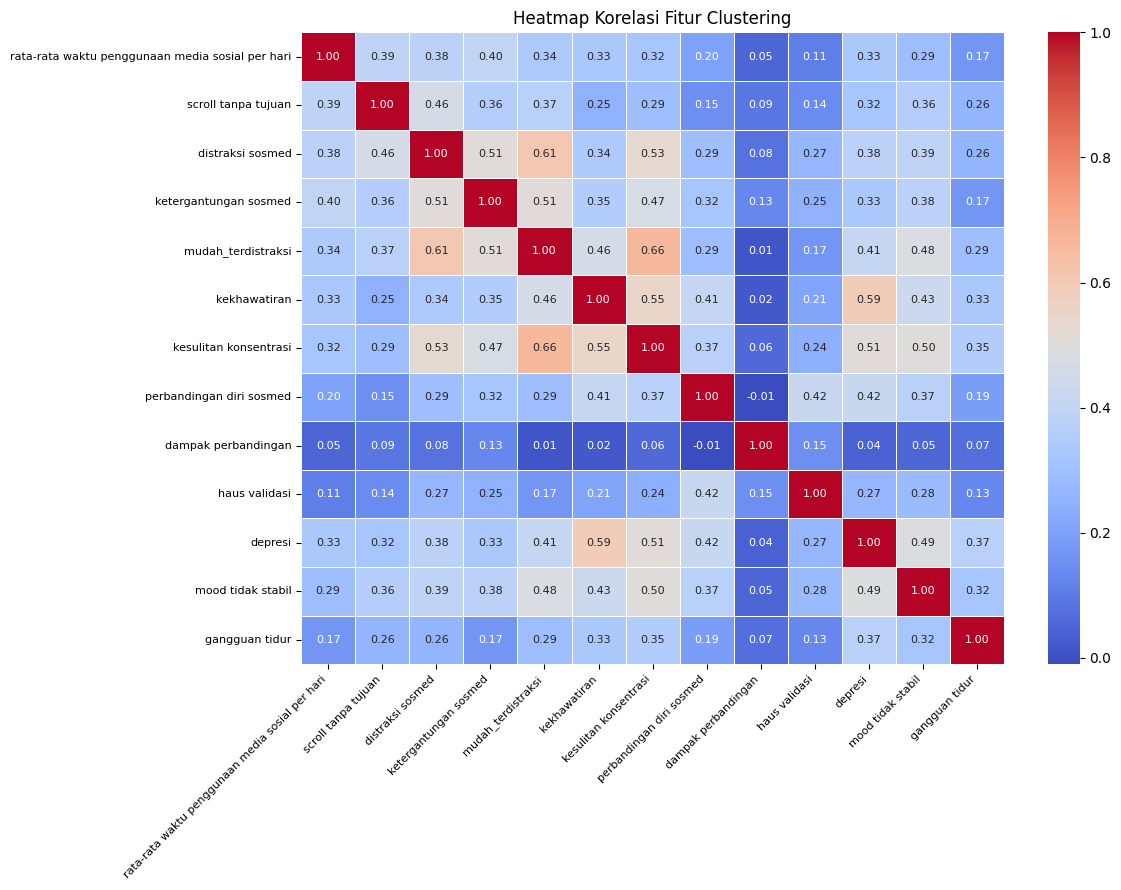

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Heatmap Korelasi Fitur Clustering')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()